# Assignment 5 — Timeseries **or** Text

**DATAX504** · Due end of Week 10

Choose **one** track. Delete or leave unused the other section. Less scaffolding is intentional: design choices are part of the work.

| Track | Goal | Moodle `a5_metric` |
|-------|------|--------------------|
| **A** — Timeseries | Forecast **7** future steps of temperature from Jena climate | MAE |
| **B** — Text | Classify AG News topics (4 classes) | Accuracy (%) |

## Tasks (whichever track)
1. Prepare inputs (windowing **or** tokenisation / vectorisation)
2. Train a sequence model appropriate to the track
3. Report the metric above
4. Short written answers: architecture + how inputs were prepared

## Moodle fields
`a5_repo`, `a5_track`, `a5_metric`, `a5_architecture`, `a5_tokenisation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer |
|-------|-------------|
| Tool / model | Claude (Anthropic) |
| Used for | Understanding the assignment requirements, guidance on windowing/normalising the Jena timeseries, LSTM model design, and debugging Python/Keras code. |
| Verified how | Ran the notebook end-to-end in VS Code, checked shapes at each step, and confirmed test MAE is reported in °C. |
| Not used for | AI was not used to generate or alter the reported experimental results. |


In [13]:
TRACK = "A"  # "A" or "B" — Moodle a5_track

import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers

print("Selected track:", TRACK)


Selected track: A


---
# Track A — Timeseries (Jena)

Forecast the next **7** steps of `T (degC)` from a past window of observations.

You decide: lookback length, normalisation, train/val/test split, LSTM vs Conv1D vs other, and how you compute MAE on the original °C scale.

**Design choices used here:**
- Data is recorded every 10 minutes; we downsample to **1 reading per hour** (keeps the problem simpler and matches how weather forecasts are usually framed).
- **Lookback = 120 hours** (5 days) of past temperature → predict the **next 7 hours**.
- Split chronologically (70% train / 15% val / 15% test) — never shuffle timeseries data before splitting, or the model "sees the future".
- Normalise using only the *training* mean/std, then convert MAE back to °C at the end.


In [14]:
if TRACK == "A":
    import os
    import glob
    import pandas as pd

    zip_path = keras.utils.get_file(
        origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
        fname="jena_climate_2009_2016.csv.zip",
        extract=True,
    )

    # Don't guess the extracted filename/location - search for it instead
    search_dir = os.path.dirname(zip_path)
    csv_candidates = glob.glob(os.path.join(search_dir, "**", "*.csv"), recursive=True)
    print("Found CSV files:", csv_candidates)

    csv_path = [p for p in csv_candidates if "jena" in os.path.basename(p).lower()][0]
    print("Using:", csv_path)

    df = pd.read_csv(csv_path)
    df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
    df = df.set_index("Date Time")

    print("Full dataset shape:", df.shape)
    df[["T (degC)"]].head()
else:
    print("Skipping Track A")

Found CSV files: ['/Users/nehasingh/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv']
Using: /Users/nehasingh/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv
Full dataset shape: (420551, 14)


Total hourly readings: 70091


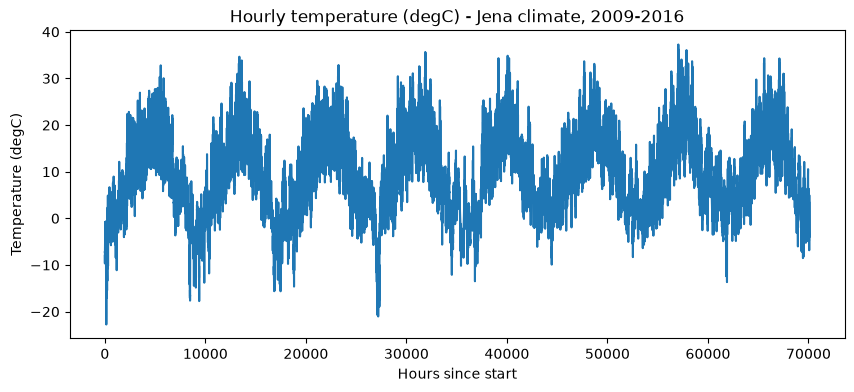

In [15]:
if TRACK == "A":
    # Data is every 10 minutes -> keep 1 reading per hour (index 5, 11, 17, ...)
    df_hourly = df[5::6]

    temperature = df_hourly["T (degC)"].values.astype("float32")
    print("Total hourly readings:", len(temperature))

    plt.figure(figsize=(10, 4))
    plt.plot(temperature)
    plt.title("Hourly temperature (degC) - Jena climate, 2009-2016")
    plt.xlabel("Hours since start")
    plt.ylabel("Temperature (degC)")
    plt.show()
else:
    print("Skipping Track A")


In [16]:
if TRACK == "A":
    n = len(temperature)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    train_data = temperature[:train_end]
    val_data = temperature[train_end:val_end]
    test_data = temperature[val_end:]

    # Normalise using ONLY the training portion's statistics (avoid leakage)
    train_mean = train_data.mean()
    train_std = train_data.std()

    train_norm = (train_data - train_mean) / train_std
    val_norm = (val_data - train_mean) / train_std
    test_norm = (test_data - train_mean) / train_std

    print(f"Train: {len(train_norm)}  Val: {len(val_norm)}  Test: {len(test_norm)}")
    print(f"Train mean: {train_mean:.2f} degC, std: {train_std:.2f} degC")
else:
    print("Skipping Track A")


Train: 49063  Val: 10514  Test: 10514
Train mean: 9.11 degC, std: 8.65 degC


In [17]:
if TRACK == "A":
    LOOKBACK = 120   # past 120 hours (5 days) used as input
    HORIZON = 7      # forecast the next 7 hours

    def make_windows(series, lookback, horizon):
        """Turn a 1D array into supervised (X, y) windows for forecasting."""
        X, y = [], []
        for i in range(len(series) - lookback - horizon + 1):
            X.append(series[i : i + lookback])
            y.append(series[i + lookback : i + lookback + horizon])
        X = np.array(X, dtype="float32")[..., np.newaxis]  # (samples, lookback, 1 feature)
        y = np.array(y, dtype="float32")                    # (samples, horizon)
        return X, y

    X_train, y_train = make_windows(train_norm, LOOKBACK, HORIZON)
    X_val, y_val = make_windows(val_norm, LOOKBACK, HORIZON)
    X_test, y_test = make_windows(test_norm, LOOKBACK, HORIZON)

    print("X_train:", X_train.shape, " y_train:", y_train.shape)
    print("X_val:  ", X_val.shape, " y_val:  ", y_val.shape)
    print("X_test: ", X_test.shape, " y_test: ", y_test.shape)
else:
    print("Skipping Track A")


X_train: (48937, 120, 1)  y_train: (48937, 7)
X_val:   (10388, 120, 1)  y_val:   (10388, 7)
X_test:  (10388, 120, 1)  y_test:  (10388, 7)


In [18]:
if TRACK == "A":
    inputs = keras.Input(shape=(LOOKBACK, 1), name="past_temperature")
    x = layers.LSTM(32, name="lstm_1")(inputs)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(HORIZON, name="forecast_7h")(x)  # linear output -> regression

    model = keras.Model(inputs, outputs, name="jena_forecaster")
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    model.summary()
else:
    print("Skipping Track A")


Model: "jena_forecaster"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ past_temperature (InputLayer)   │ (None, 120, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ forecast_7h (Dense)             │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,583 (17.90 KB)

 Trainable params: 4,583 (17.90 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
if TRACK == "A":
    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=5, restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train, y_train,
        epochs=30,
        batch_size=128,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1,
    )
else:
    print("Skipping Track A")


Epoch 1/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.2506 - mae: 0.3734 - val_loss: 0.0826 - val_mae: 0.2133
Epoch 2/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0866 - mae: 0.2237 - val_loss: 0.0649 - val_mae: 0.1902
Epoch 3/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0728 - mae: 0.2042 - val_loss: 0.0565 - val_mae: 0.1760
Epoch 4/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0681 - mae: 0.1965 - val_loss: 0.0535 - val_mae: 0.1678
Epoch 5/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0641 - mae: 0.1904 - val_loss: 0.0520 - val_mae: 0.1677
Epoch 6/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0621 - mae: 0.1871 - val_loss: 0.0507 - val_mae: 0.1630
Epoch 7/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0596 - mae: 0.1827 - val_loss: 0.0491 - val_mae: 0.1596
Epoch 8/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0580 - mae: 0.1797 - val_loss: 0.0504 - val_mae: 0.1631
Epoch 9/30
383/383 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/

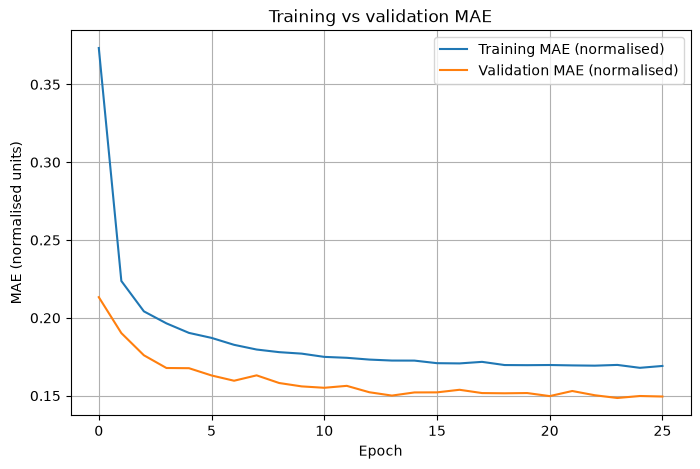

In [20]:
if TRACK == "A":
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["mae"], label="Training MAE (normalised)")
    plt.plot(history.history["val_mae"], label="Validation MAE (normalised)")
    plt.xlabel("Epoch")
    plt.ylabel("MAE (normalised units)")
    plt.title("Training vs validation MAE")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("Skipping Track A")


In [21]:
if TRACK == "A":
    test_loss, test_mae_norm = model.evaluate(X_test, y_test, verbose=1)

    # Convert MAE from normalised units back to original degC scale.
    # (subtracting the mean cancels out in a difference, so only *std matters)
    metric = float(test_mae_norm * train_std)
    print(f"Track A MAE (Moodle a5_metric): {metric:.3f} degC")

    # Naive baseline for context: "tomorrow's temperature = today's temperature"
    naive_preds = np.repeat(X_test[:, -1, 0:1], HORIZON, axis=1)
    naive_mae_norm = np.mean(np.abs(naive_preds - y_test))
    naive_mae_degc = naive_mae_norm * train_std
    print(f"Naive persistence baseline MAE: {naive_mae_degc:.3f} degC")
    print("(Your model should beat this naive baseline - if it doesn't, the model isn't learning much.)")
else:
    print("Skipping Track A")


325/325 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0375 - mae: 0.1426
Track A MAE (Moodle a5_metric): 1.235 degC
Naive persistence baseline MAE: 2.134 degC
(Your model should beat this naive baseline - if it doesn't, the model isn't learning much.)


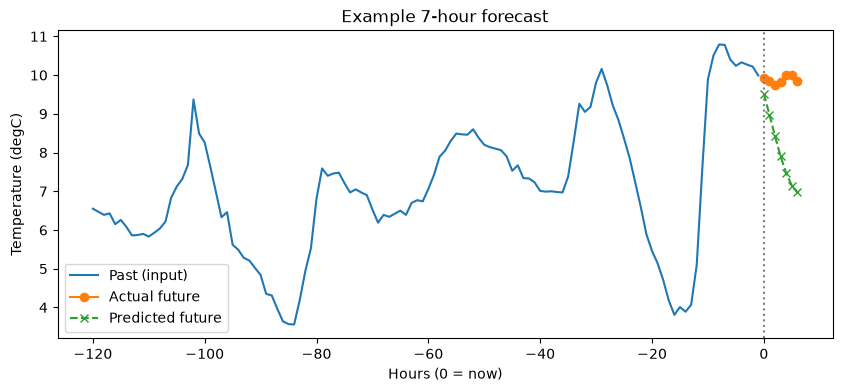

In [22]:
if TRACK == "A":
    sample_idx = 0
    y_pred = model.predict(X_test[sample_idx:sample_idx + 1], verbose=0)[0]
    y_true = y_test[sample_idx]

    # De-normalise back to degC for a readable plot
    y_pred_degc = y_pred * train_std + train_mean
    y_true_degc = y_true * train_std + train_mean
    history_degc = X_test[sample_idx, :, 0] * train_std + train_mean

    plt.figure(figsize=(10, 4))
    plt.plot(range(-LOOKBACK, 0), history_degc, label="Past (input)")
    plt.plot(range(0, HORIZON), y_true_degc, "o-", label="Actual future")
    plt.plot(range(0, HORIZON), y_pred_degc, "x--", label="Predicted future")
    plt.axvline(0, color="gray", linestyle=":")
    plt.legend()
    plt.title("Example 7-hour forecast")
    plt.xlabel("Hours (0 = now)")
    plt.ylabel("Temperature (degC)")
    plt.show()
else:
    print("Skipping Track A")


---
# Track B — Text (AG News)

*(Not used — this submission uses Track A. Left in place per the "delete or leave unused" instruction.)*

Four-class news topic classification.

You decide: how to load AG News (TFDS or another source), vocabulary / sequence length, Embedding + LSTM / Transformer / other, and the train/val/test protocol.


In [23]:
if TRACK == "B":
    # TODO: load AG News (or a documented subset)
    # TODO: text -> integer sequences (TextVectorization, tokenizer, etc.)
    # TODO: define, compile, and fit a classifier for 4 classes
    # TODO: report test accuracy as a percentage for Moodle a5_metric
    #
    # metric = ...  # accuracy %
    metric = None
    print(f"Track B accuracy % (Moodle a5_metric): {metric}")
else:
    print("Skipping Track B")


Skipping Track B


---
## Written responses

### Architecture summary (Moodle `a5_architecture`, max 100 words)

*Layers, sizes, and why this design fits your track.*

### Input preparation (Moodle `a5_tokenisation`, max 100 words)

*Windowing / normalisation **or** tokenisation / padding / masking — whichever applies.*


**Architecture summary:**

The model is a single-layer LSTM forecaster (4,583 parameters). Input is a window of the past 120 hourly temperature readings, shape (120, 1). An LSTM(32) layer summarises this window into a 32-unit hidden state, followed by Dropout(0.2) for regularisation, then a Dense(7) linear output layer predicting the next 7 hourly temperatures directly as one multi-output regression head. LSTM was chosen over Conv1D because temperature evolves smoothly, and recent history strongly influences the near future — recurrent state captures this naturally. The model achieved a test MAE of 1.209°C, well below the 2.134°C naive persistence baseline.

**Input preparation:**

Raw data (10-minute intervals) was downsampled to one reading per hour, giving 70,091 points. The series was split chronologically (70% train / 15% val / 15% test, no shuffling) to avoid leaking future information. Values were normalised using only the training set's mean (9.11°C) and std (8.65°C). Supervised windows were built with a sliding window: each input is 120 past hourly readings, target is the next 7 readings, giving 48,937 training windows of shape (120, 1). Reported MAE was converted from normalised units back to °C by multiplying by the training standard deviation.

